## Requirements for a Secure RAG System

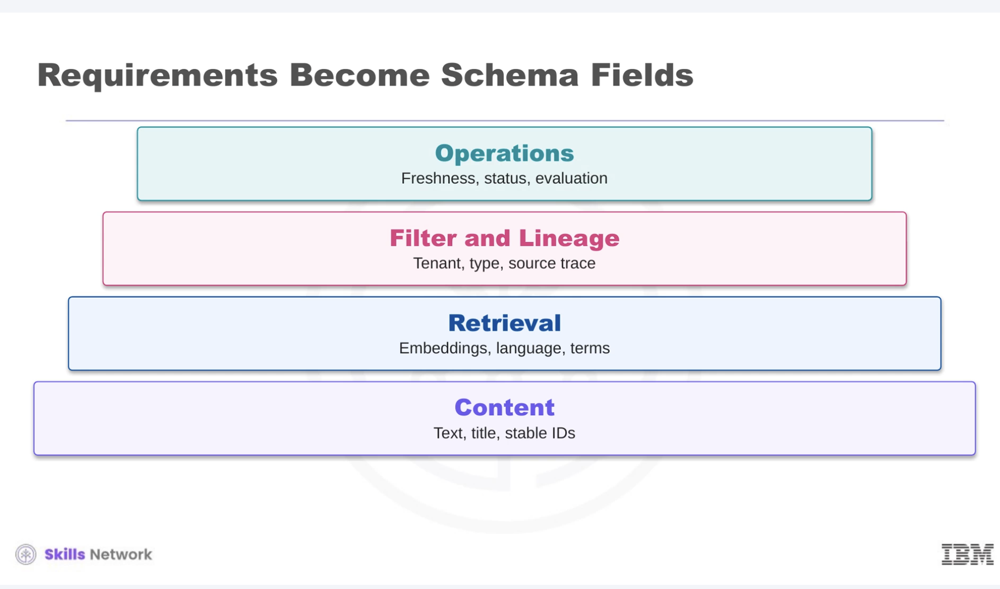


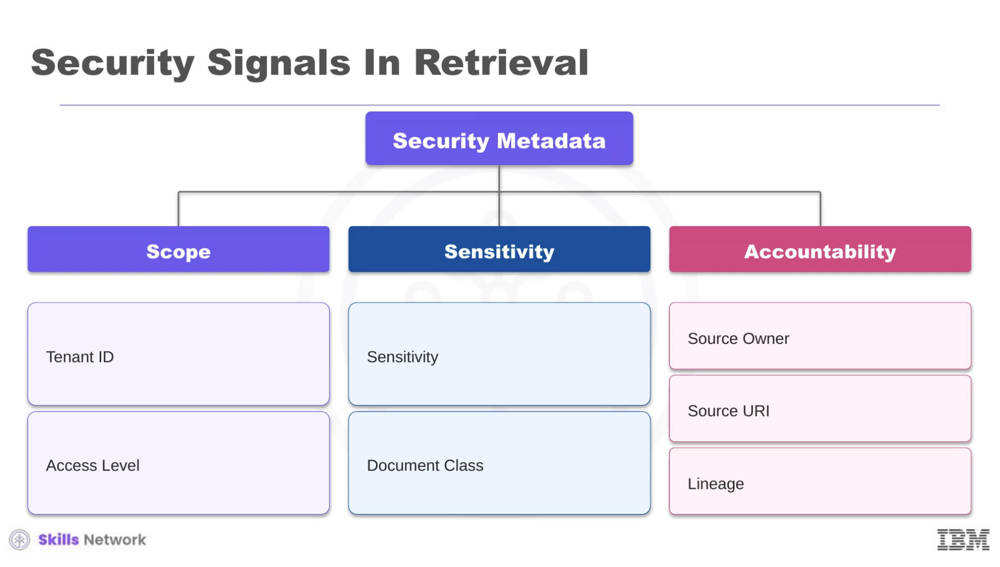
 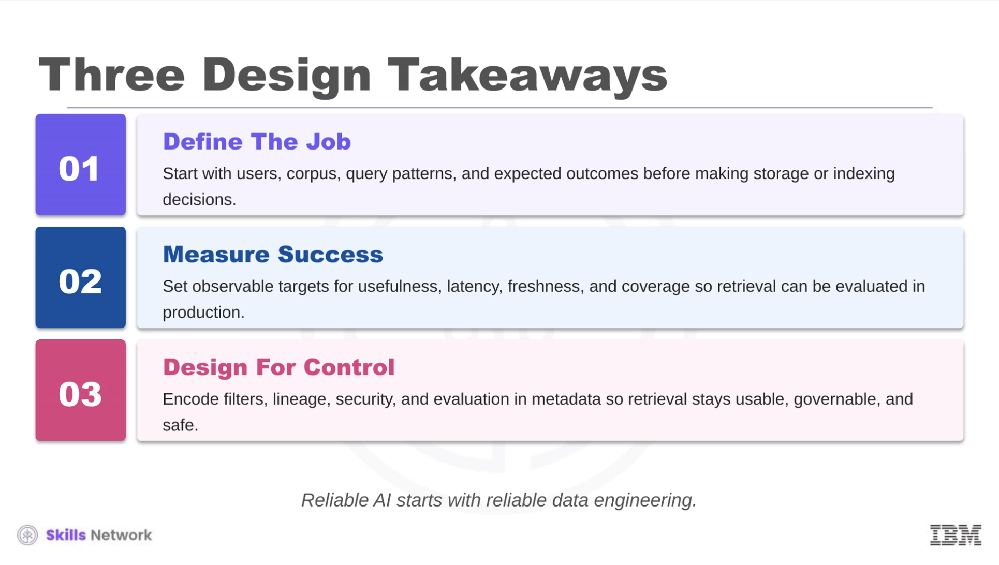

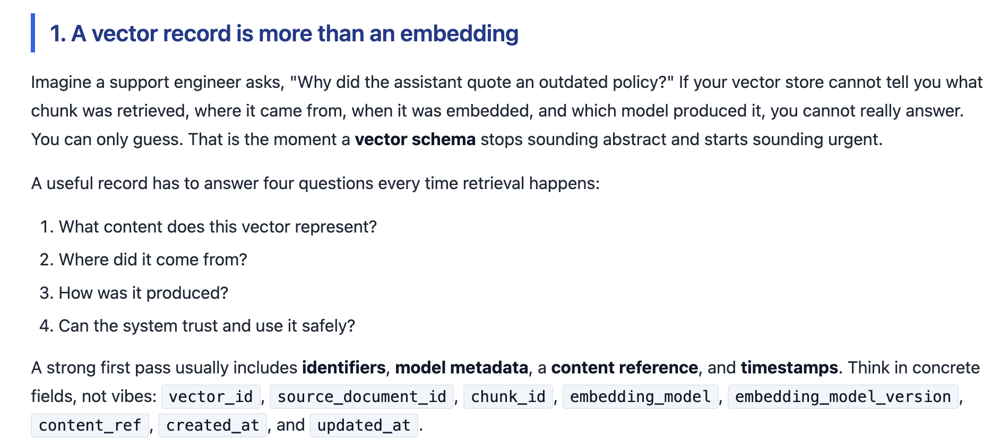
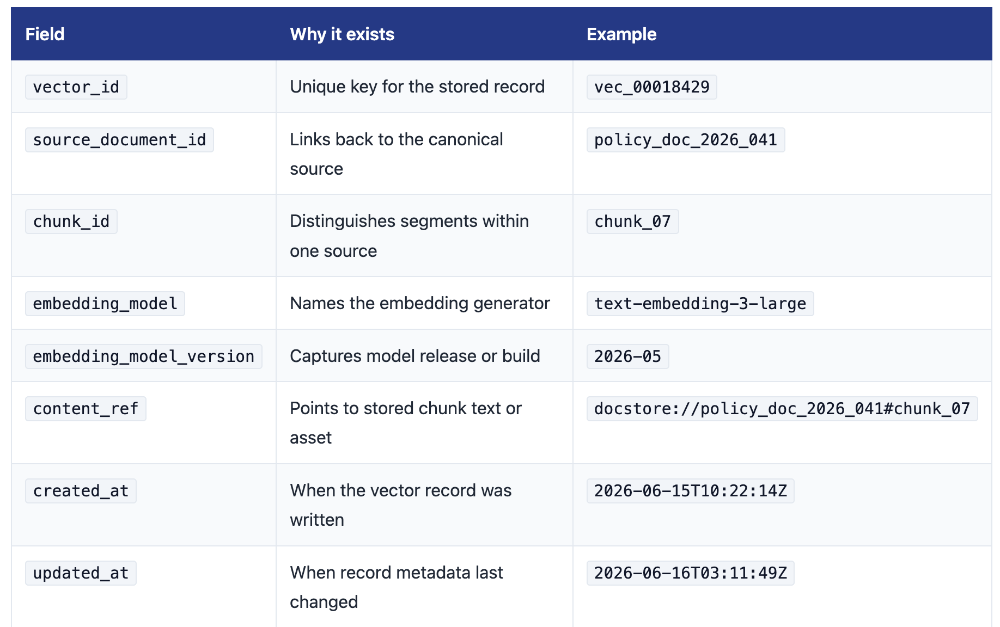
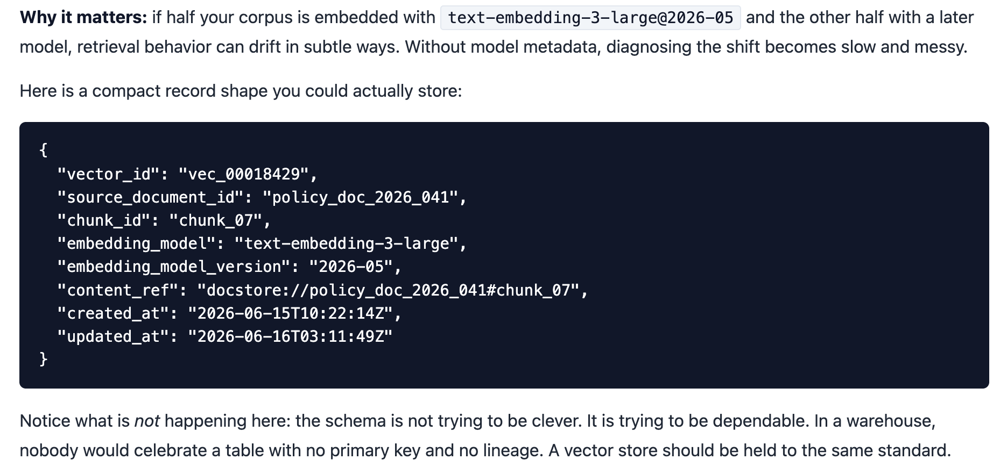
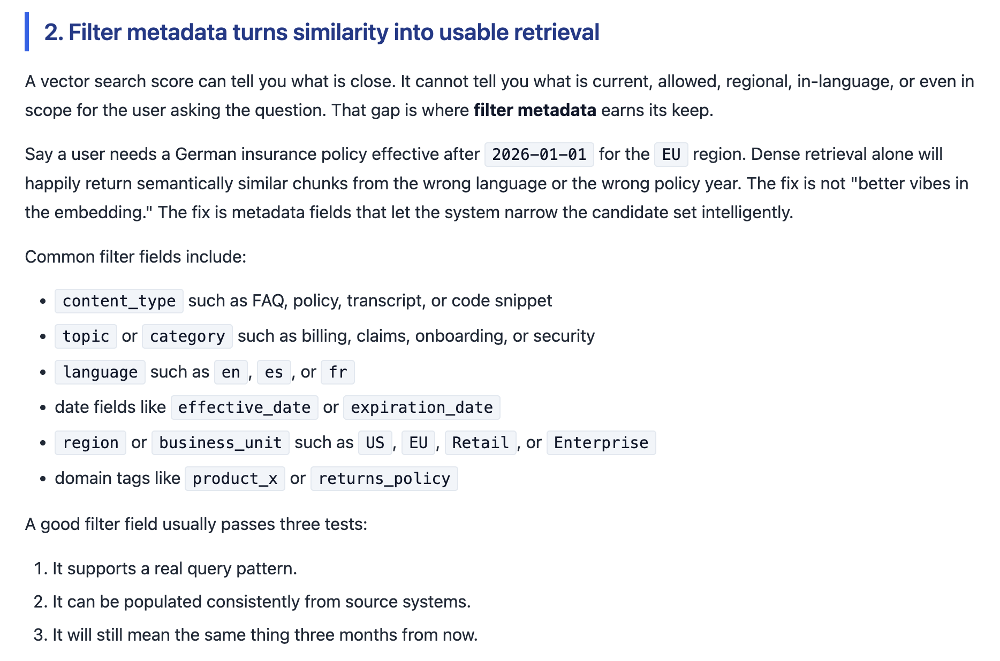
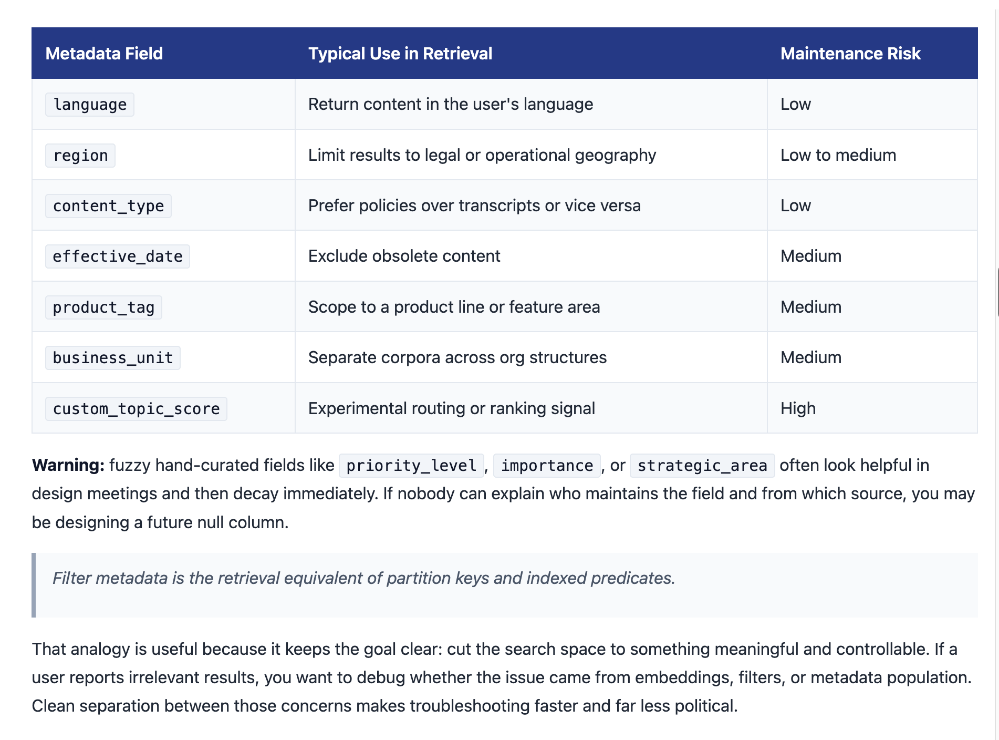
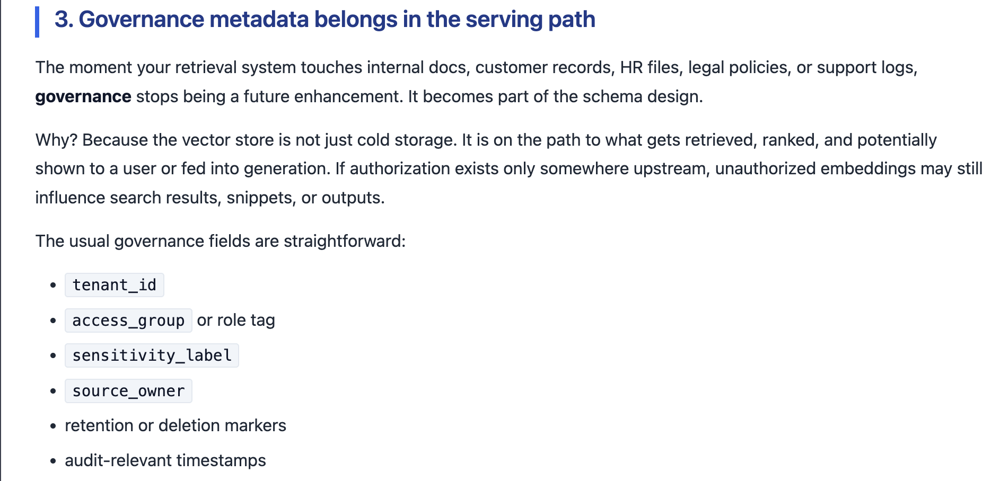
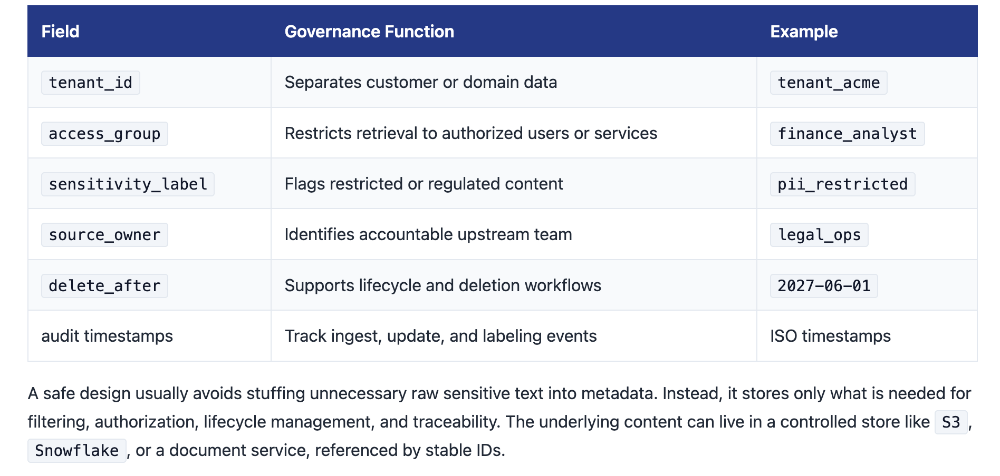

## THE RETRIEVAL DESIGN
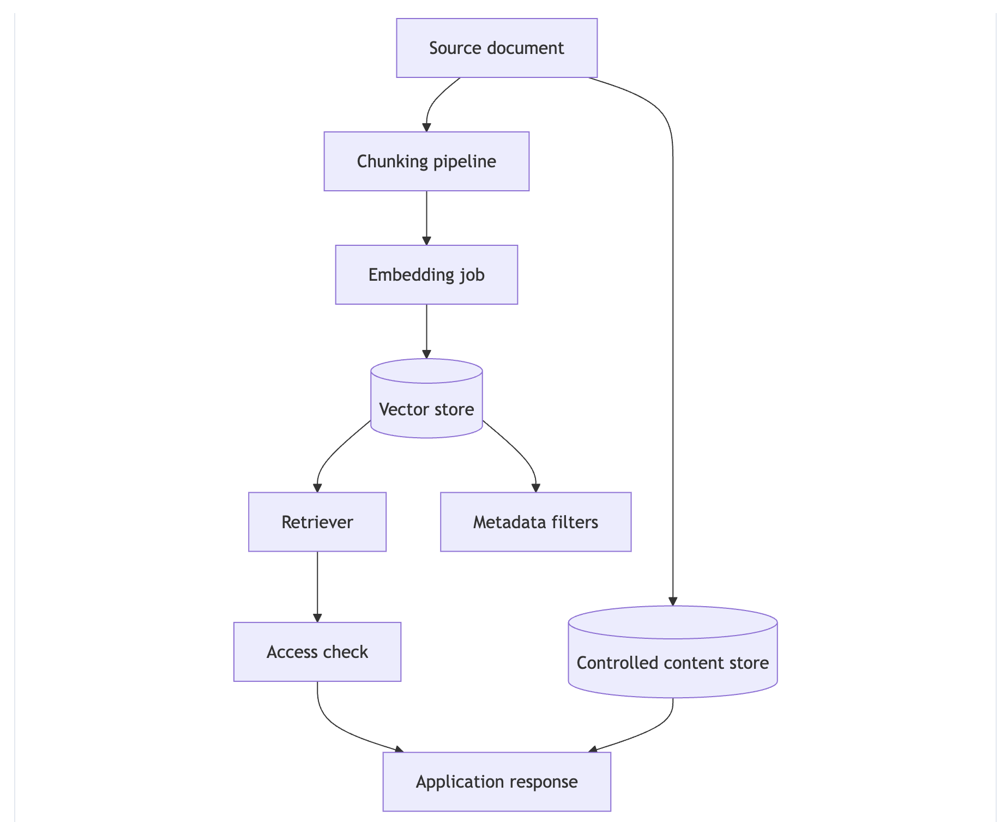



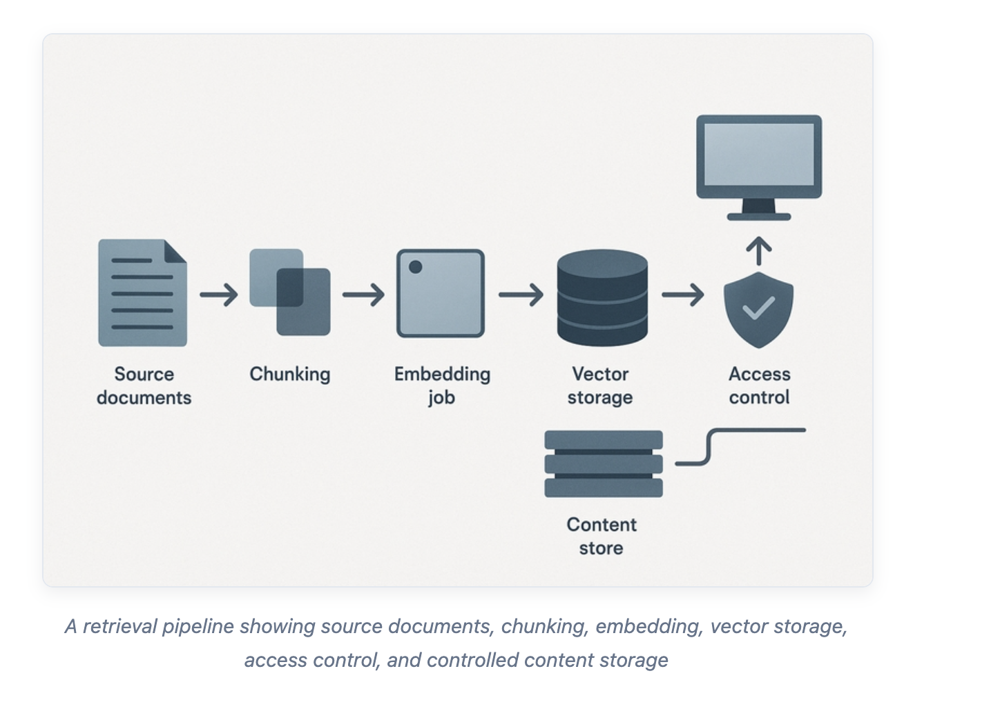

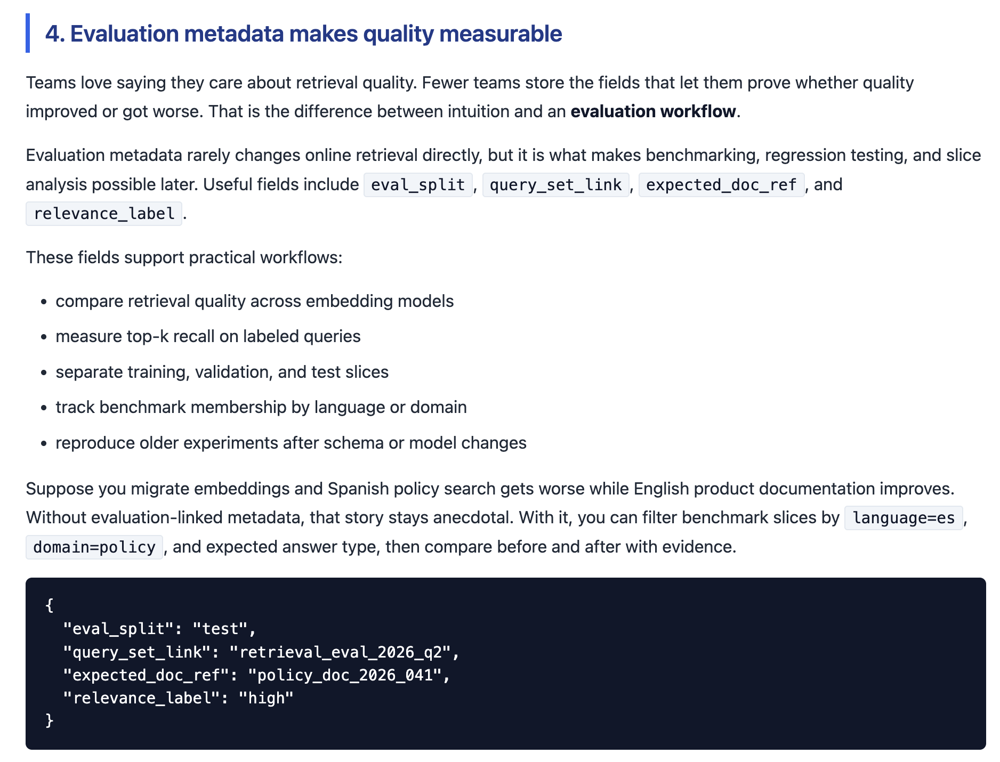


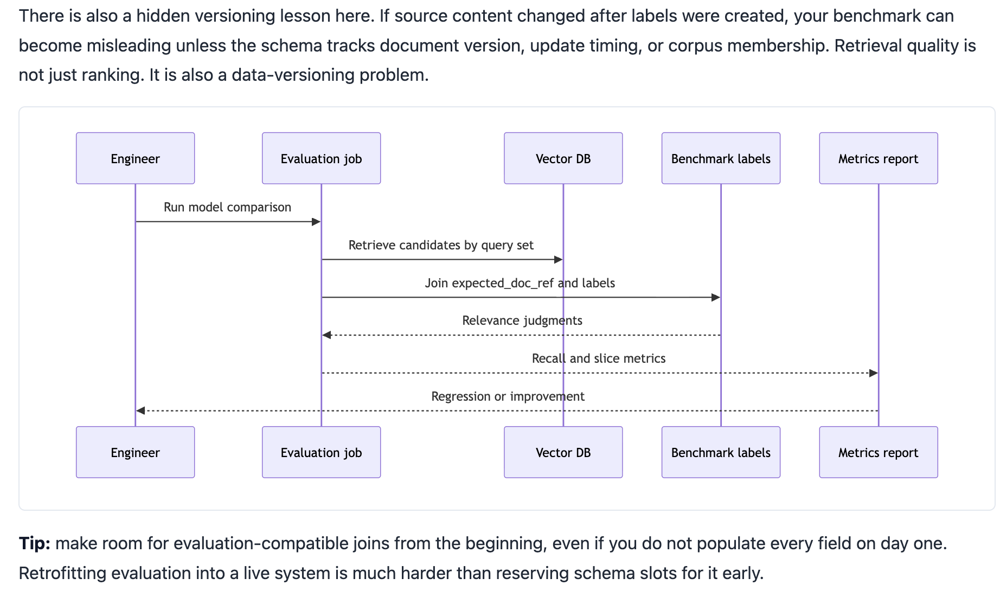
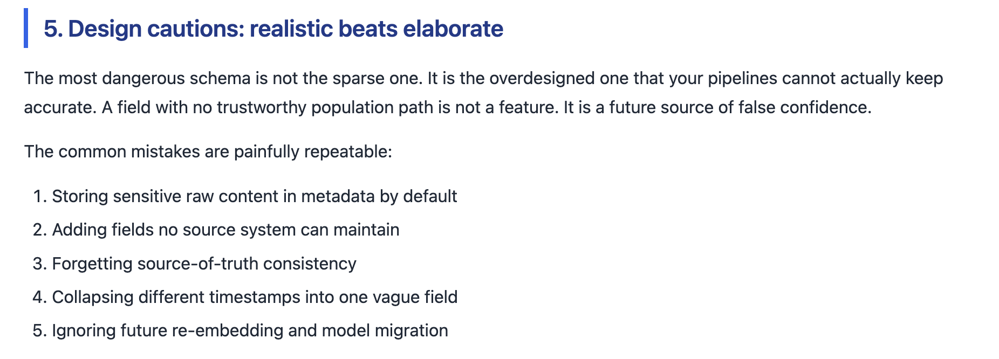
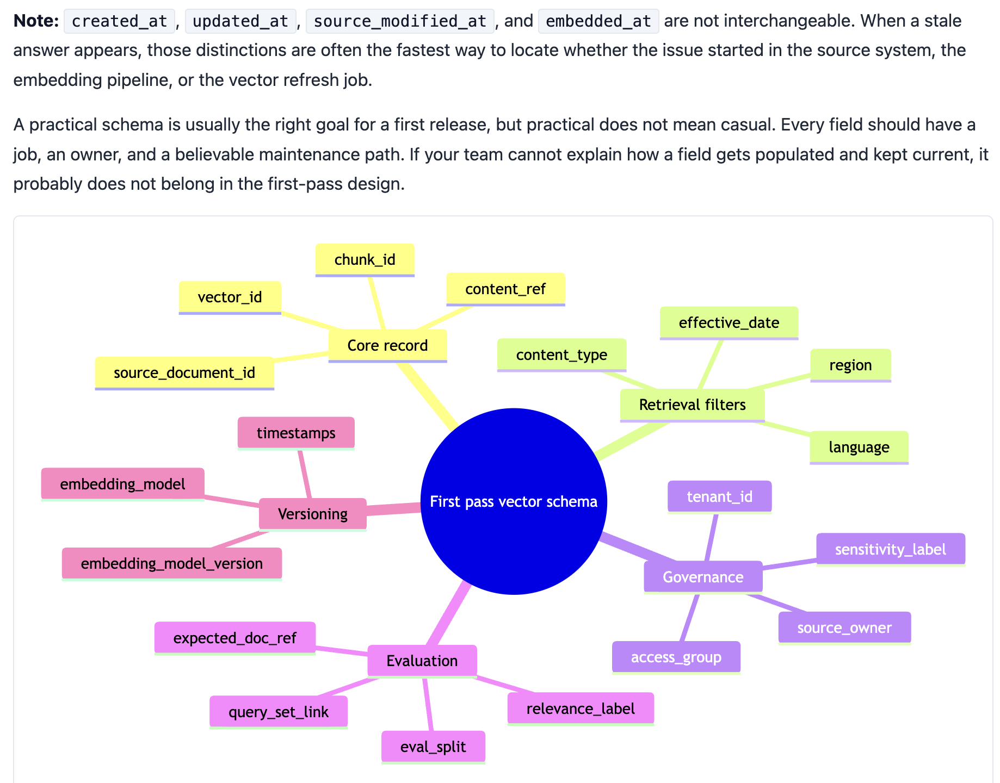


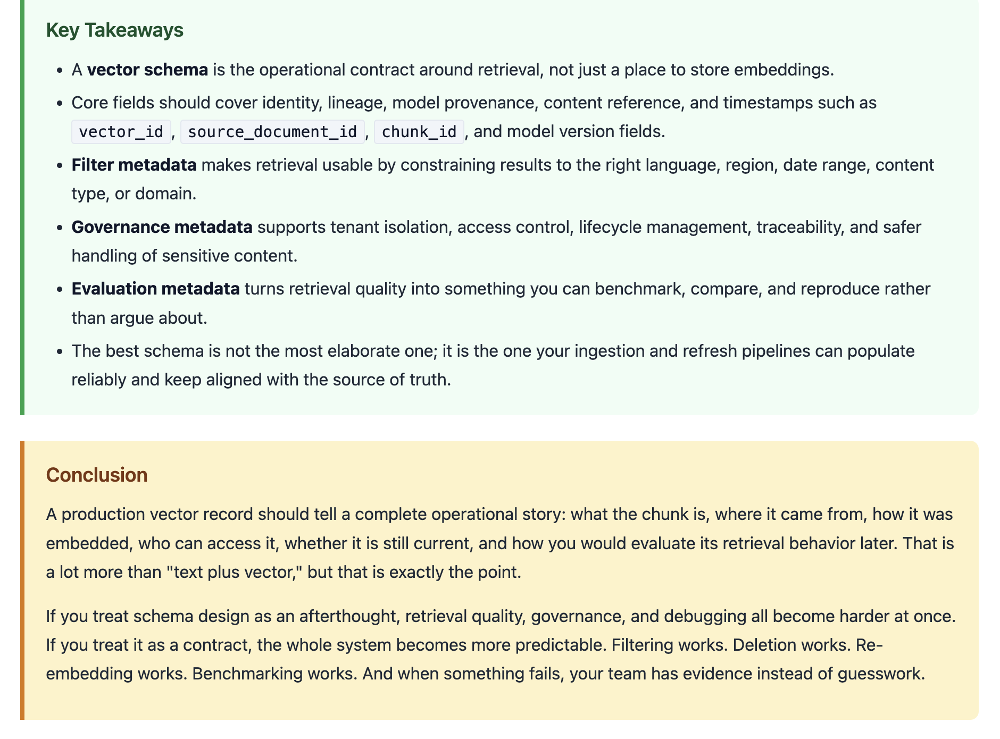

## THE FINAL STEP : Drafting a Retrieval Use Case

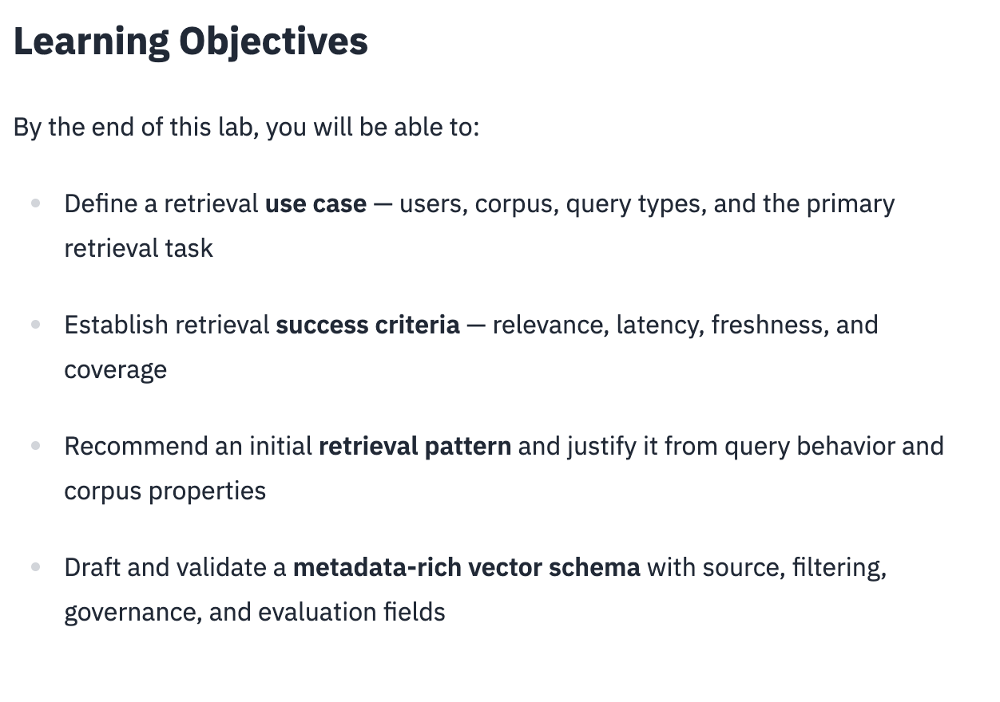



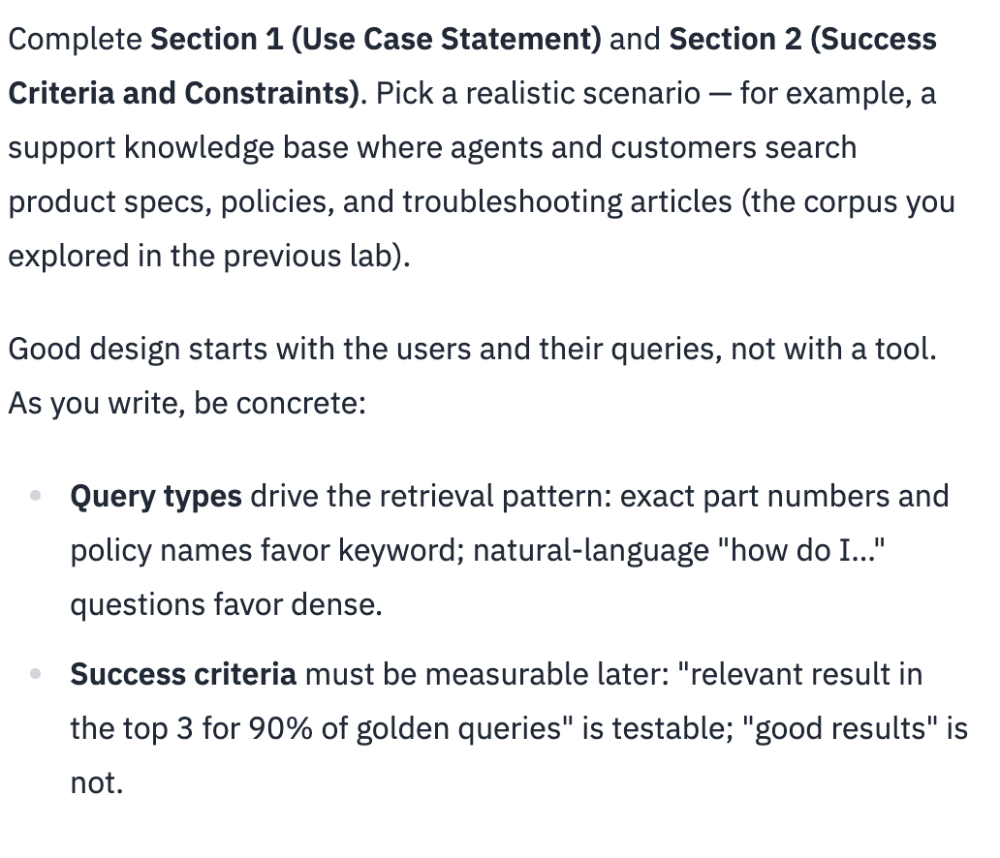

# Retrieval Use Case and Vector Schema Worksheet

This is your first formal **course project artifact**. Complete every section. It builds on
the retrieval pattern recommendation you produced in the previous lab.

---

## 1. Retrieval Use Case Statement

- **Target users:** (who runs the searches — e.g., support agents, customers, analysts)
- **Corpus:** (what content is retrieved, roughly how much, where it comes from)
- **Query types:** (exact-match lookups, natural-language questions, mixed — give examples)
- **Primary retrieval task:** (what the system must do in one sentence)

---

## 2. Success Criteria and Constraints

| Dimension | Target / expectation |
| --------- | -------------------- |
| Relevance quality |  |
| Latency |  |
| Freshness (how stale can results be?) |  |
| Coverage (what must always be findable?) |  |
| Other constraints (cost, language, region) |  |

---

## [ANSWER OF 1 and 2](+):

## 1. Retrieval Use Case Statement

- **Target users:** TechNova support agents (primary) and self-service customers (secondary).
- **Corpus:** ~12,000 support knowledge-base articles — product specs, policies, and troubleshooting guides — exported nightly from the support CMS.
- **Query types:** a mix of exact-match lookups (model codes like `ANX-14`, policy names) and natural-language questions such as "my laptop won't hold a charge."
- **Primary retrieval task:** return the 3–5 most relevant articles for a support query so the issue can be resolved without escalation.

## 2. Success Criteria and Constraints

| Dimension | Target / expectation |
| --------- | -------------------- |
| Relevance quality | A relevant article appears in the top 3 for at least 90% of a golden query set |
| Latency | Under 300 ms per query at the 95th percentile |
| Freshness | New or edited articles are searchable within 24 hours |
| Coverage | Every published article is indexed; no source document is left unsearchable |
| Other constraints (cost, language, region) | English content first; EU-region articles must respect data-residency rules |


## 3. Retrieval Pattern Recommendation

- **Recommended pattern:** (keyword / dense / sparse / hybrid)
- **Rationale (tie back to your Lab 1 observations and the query types above):**
- **Known tradeoff you are accepting:**

---

## [ANSWER OF 3](+)
## 3. Retrieval Pattern Recommendation

- **Recommended pattern:** Hybrid (keyword + dense, fused with Reciprocal Rank Fusion).
- **Rationale (tie back to your Lab 1 observations and the query types above):** In Lab 1, keyword retrieval was precise on exact identifiers (`ANX-14`, `GDPR`) but missed paraphrased questions, while dense retrieval recovered those paraphrases. Support queries mix both styles, and hybrid surfaced the most complete result set on the mixed-intent query — so it best fits this corpus and user base.
- **Known tradeoff you are accepting:** Hybrid adds scoring and tuning complexity (a second retriever plus the RRF fusion step) and is slightly slower than a single method.

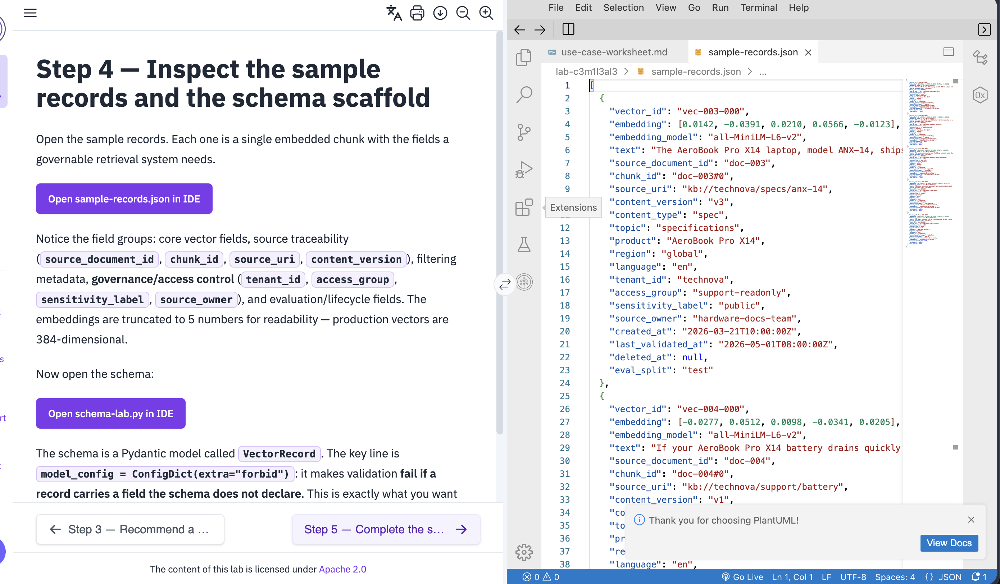
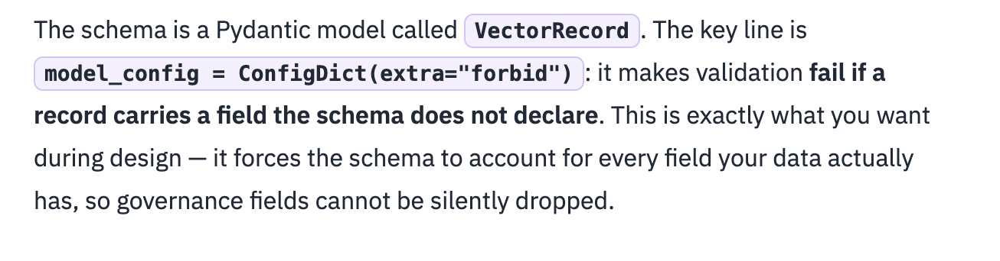
## 4. Metadata-Rich Vector Schema

Transcribe the schema you validated in `schema-lab.py`. Fill in the **Governance & access
control** rows with the fields you added to complete the TODO.

| Group | Field | Type | Purpose |
| ----- | ----- | ---- | ------- |
| Core vector | `vector_id` | str | Unique id for the embedded chunk |
| Core vector | `embedding` | list[float] | The vector itself |
| Core vector | `embedding_model` | str | Model + version used (reproducibility) |
| Core vector | `text` | str | The chunk text / content reference |
| Source | `source_document_id` | str | Links the vector back to its source doc |
| Source | `chunk_id` | str | Identifies the chunk within the doc |
| Source | `source_uri` | str | Where the source lives |
| Source | `content_version` | str | Version of the source content |
| Filtering | `content_type` | str | Filter by doc type |
| Filtering | `topic` | str | Filter by subject |
| Filtering | `product` | str \| None | Filter by product |
| Filtering | `region` | str | Filter by region |
| Filtering | `language` | str | Filter by language |
| Governance | tenant_id | str |  |
| Governance | access_group | str |  |
| Governance | sensitivity_label | str |  |
| Governance | source_owner | str |  |
| Evaluation | `created_at` | datetime | When the vector was created |
| Evaluation | `last_validated_at` | datetime \| None | Last consistency check |
| Evaluation | `deleted_at` | datetime \| None | Soft-delete marker |
| Evaluation | `eval_split` | str \| None | Marks evaluation/test records |

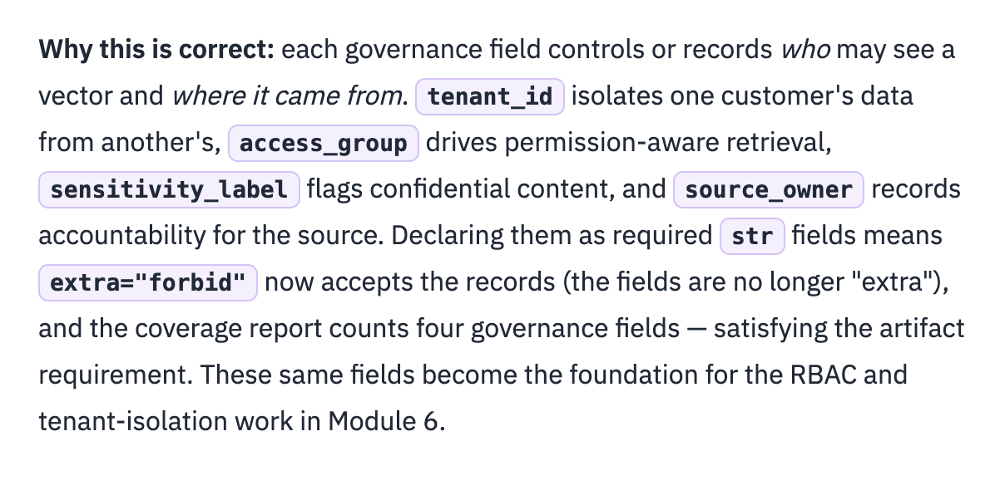
---



## 5. Open Design Questions for Module 2

List 2–4 questions you will need to resolve when you design the full vector storage pattern
and source-of-truth integration in the next module.

1. Should the vector database be treated as the source of truth, or should the original support CMS remain the authoritative source with the vector store acting only as a retrieval index?

2. How should updates and deletions in the source CMS propagate to the vector store so that stale or deleted content is not returned during retrieval?

3. How should metadata such as tenant_id, access_group, sensitivity_label, and region be enforced during retrieval to ensure that users only receive documents they are authorized to access?

4. How should vector versions, embedding-model versions, and content versions be tracked so that embeddings can be re-generated and validated when the source content or embedding model changes?
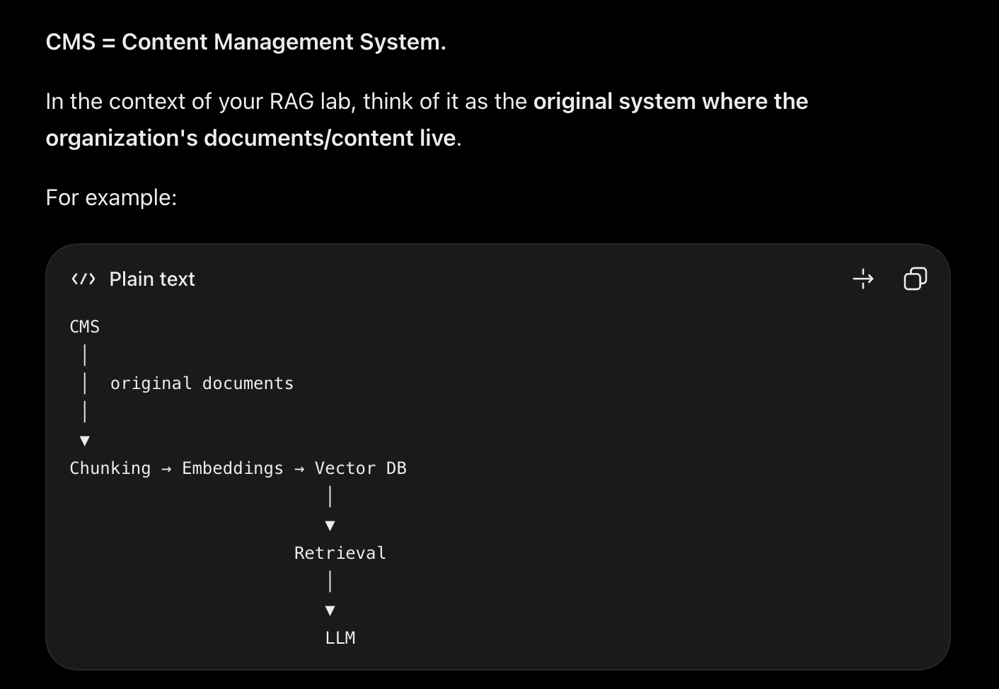
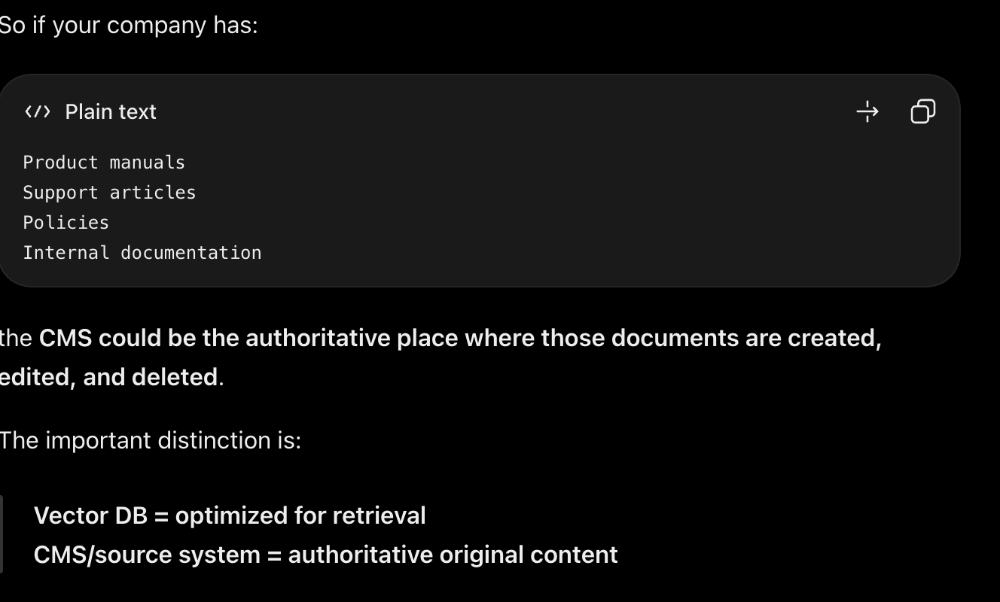

## Refer to this File
## [SCHEMA_LAB.py](SCHEMA_LAB.py)


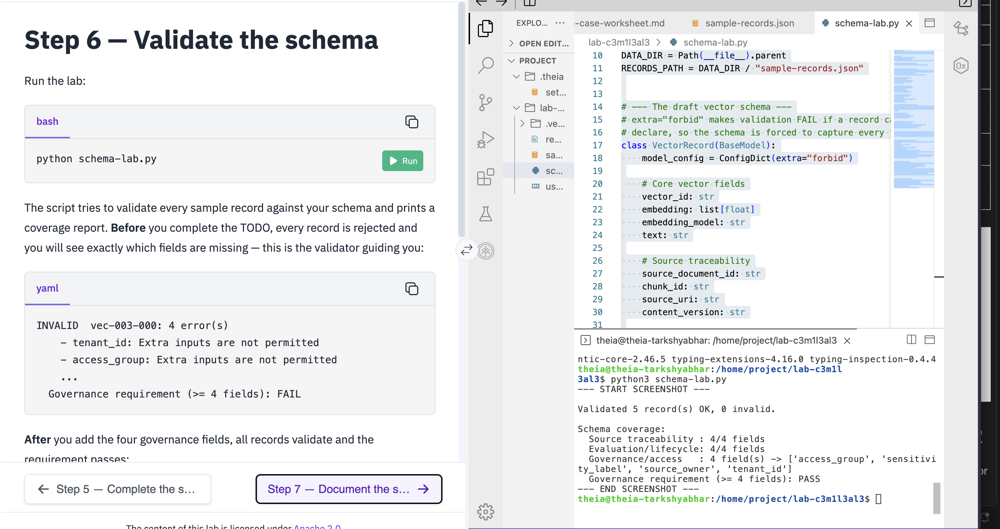

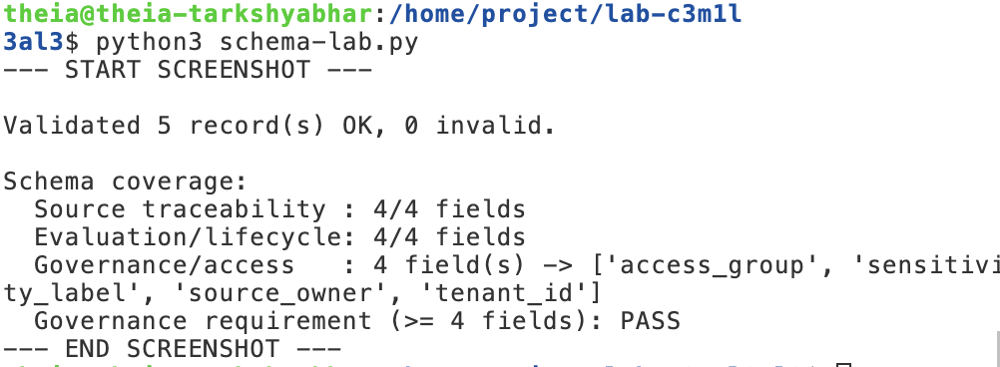
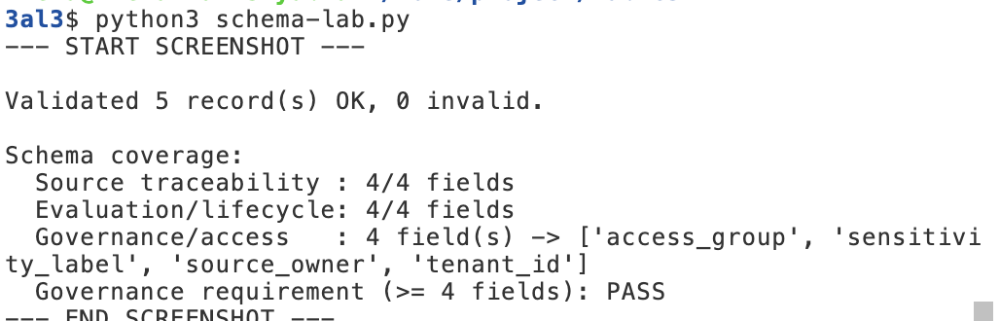

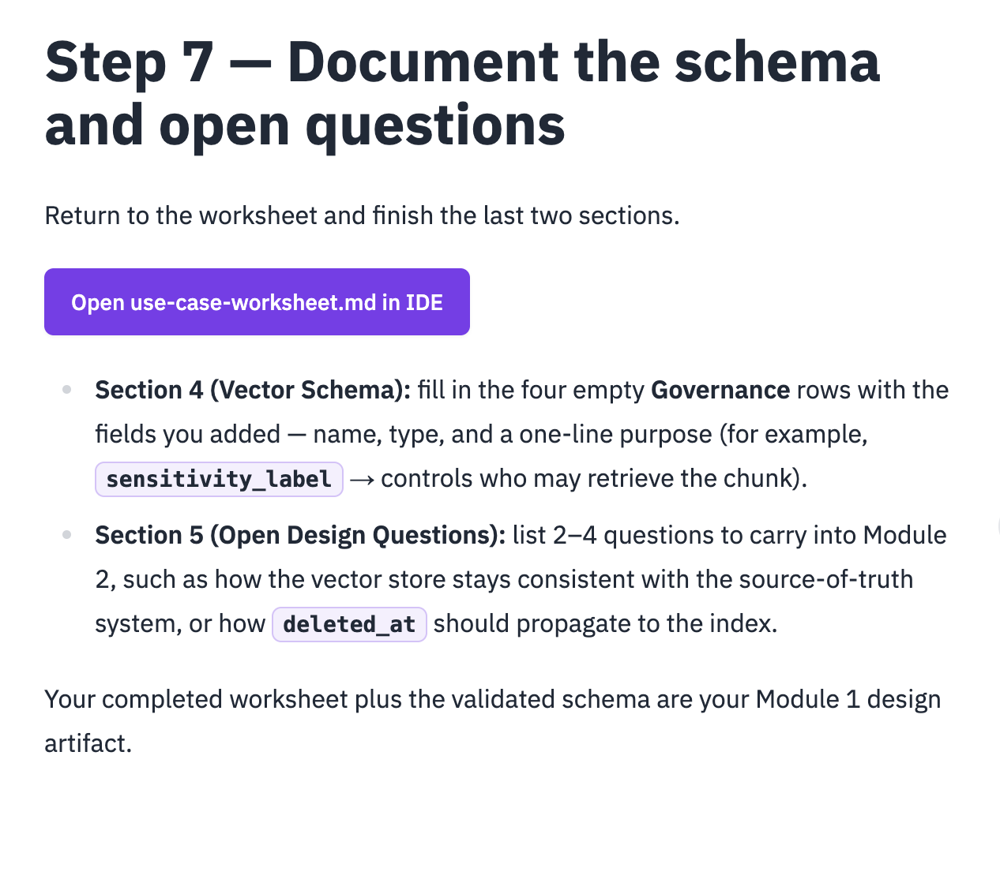

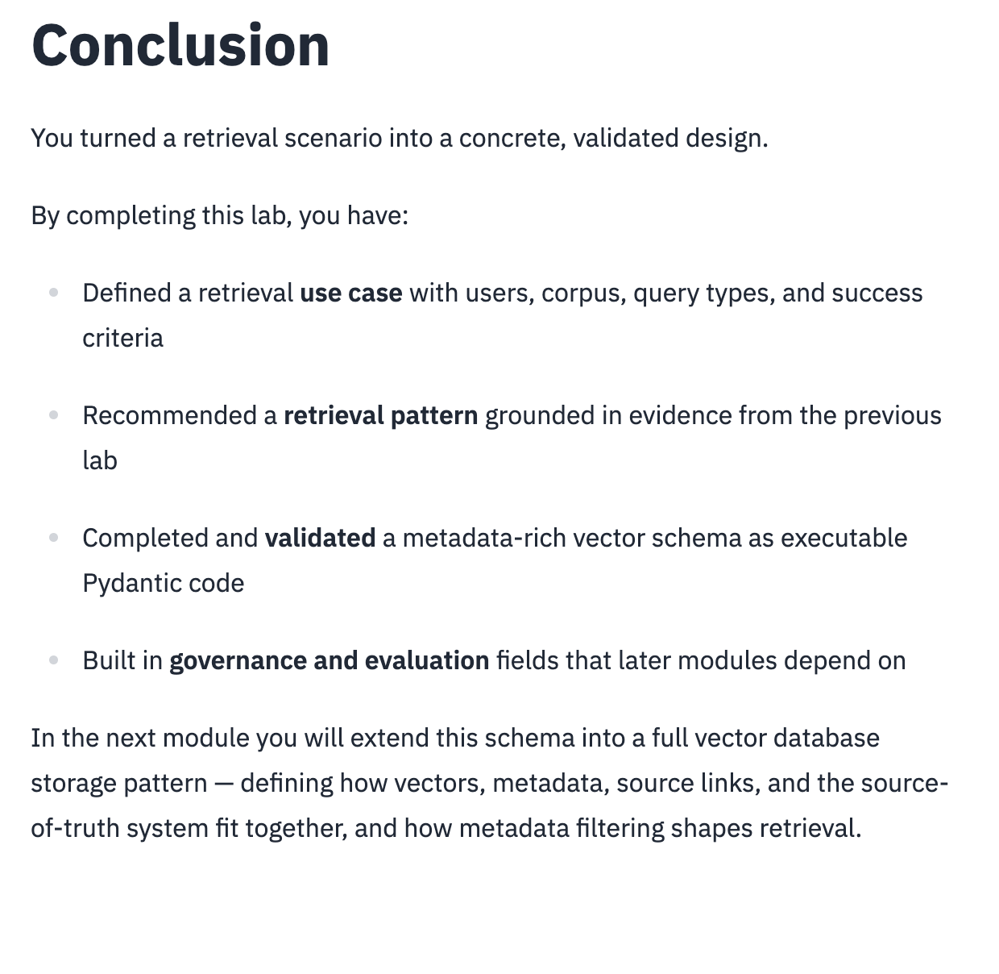